# Predicción de la cantidad de muertes de un jugador

Este notebook muestra un ejemplo de cómo **convertir un problema de predicción del número de muertes** que hará un jugador en un problema de **clasificación**, entrenar un modelo de *machine learning* y evaluar sus métricas (precisión, recall, F1) junto con la **matriz de confusión**.

> ⚠️ *Si preferieras un enfoque de regresión (predecir el número exacto), bastaría con cambiar el modelo por un regresor y las métricas por RMSE, MAE, etc. Aquí, para cumplir con tu solicitud de métricas de precisión y matriz de confusión, discretizamos las muertes en rangos.*

## 1. Instalación de dependencias
Ejecuta esta celda solo si trabajas en Google Colab y aún no tienes instaladas las bibliotecas necesarias.

In [1]:
# @title Instalar bibliotecas (solo Colab)
!pip -q install scikit-learn pandas matplotlib seaborn


## 2. Importar bibliotecas

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


## 3. Carga del conjunto de datos
Sube tu archivo **`engineered_data.csv`** (o el que corresponda) con el siguiente diálogo.

In [3]:
path = r'C:\Users\LuisSalamanca\Desktop\Duoc\Machine\ML_Proyecto_Semestral\data\03_features\engineered_data.csv'

try:
    df = pd.read_csv(path, sep=',', low_memory=False)
    print(f'Dataset cargado: {df.shape}')
except Exception as e:
    print(f"Error al cargar los datos: {e}")
    
print(f"Dimensiones del dataset: {df.shape}")
df.head()


Dataset cargado: (78744, 6)
Dimensiones del dataset: (78744, 6)


,EconomicEfficiency,EffectivenessScore,EquipmentAdvantage,KillAssistRatio,StealthKillsRatio,KDA
0,0.0,0,-130.0,0.0,0.0,0.0
1,0.0,0,-80.0,0.0,0.0,0.0
2,0.0,0,120.0,0.0,0.0,0.0
3,0.0,0,-30.0,0.0,0.0,0.0
4,0.0,0,120.0,0.0,0.0,0.0


In [5]:
df['KillAssistRatio'].describe()

count    78744.000000
mean         0.631411
std          0.853987
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: KillAssistRatio, dtype: float64

## 4. Ingeniería de características y creación de la variable objetivo
Convertimos la variable numérica `deaths` en clases (baja, media, alta, muy alta). Ajusta los límites (`bins`) según tu dominio o distribución.

In [10]:
target_col = 'KillAssistRatio'  # Cambia si tu columna tiene otro nombre

# Definimos los cortes para las clases
bins = [0, 1, 2, 4, df[target_col].max()]
labels = ['Baja', 'Media', 'Alta', 'Muy alta']

df['death_class'] = pd.cut(df[target_col], bins=bins, labels=labels)

print(df['death_class'].value_counts())


death_class
Baja        24186
Media        8597
Alta         3129
Muy alta       67
Name: count, dtype: int64


## 5. División de datos en entrenamiento y prueba

In [14]:
df = df.dropna(subset=['death_class'])

In [15]:
# Eliminamos columnas no deseadas (incluyendo la original 'deaths')
X = df.drop(columns=[target_col, 'death_class'])
y = df['death_class']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño de entrenamiento: {X_train.shape}, prueba: {X_test.shape}')


Tamaño de entrenamiento: (28783, 5), prueba: (7196, 5)


## 6. Entrenamiento del modelo

In [16]:
# Pipeline con estandarización + Random Forest
pipe = make_pipeline(
    StandardScaler(with_mean=False),
    RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
)

pipe.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler(with_mean=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## 7. Evaluación del modelo

=== Informe de clasificación ===
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00       626
        Baja       1.00      1.00      1.00      4837
       Media       1.00      1.00      1.00      1720
    Muy alta       1.00      1.00      1.00        13

    accuracy                           1.00      7196
   macro avg       1.00      1.00      1.00      7196
weighted avg       1.00      1.00      1.00      7196

Exactitud global: 1.000


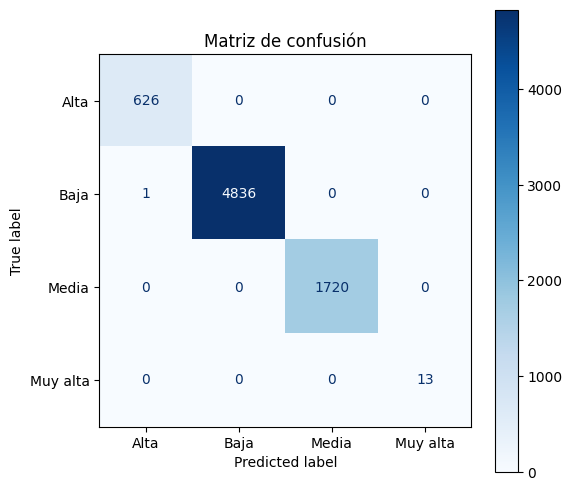

In [17]:
y_pred = pipe.predict(X_test)

print('=== Informe de clasificación ===')
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f'Exactitud global: {acc:.3f}')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()


## 8. Conclusiones
- **Clasificación vs. regresión**: En este ejemplo tratamos el problema como clasificación. Si te interesa la predicción exacta, sustituye `RandomForestClassifier` por `RandomForestRegressor` (o cualquier otro modelo de regresión) y evalúa con métricas como RMSE.
- **Ajuste de clases**: Revisa la distribución de muertes y ajusta los cortes para equilibrar clases.
- **Ingeniería de características**: Añadir más características (por ejemplo, KPIs de desempeño, tipo de arma, mapa, etc.) puede mejorar el rendimiento del modelo.
- **Validación cruzada**: Para resultados más estables, emplea `cross_val_score` o una búsqueda de hiperparámetros con `GridSearchCV`.